# QuTiP validation of the adaptive receiver

The main receiver simulation calculates click probabilities directly from
the known statistics of coherent states.

Here, the same two-stage adaptive receiver is simulated explicitly in a
truncated Fock space using QuTiP.

The input pulse is divided into two temporal modes,

$$
|\pm\alpha\rangle
\rightarrow
\left|\pm\frac{\alpha}{\sqrt{2}}\right\rangle
\otimes
\left|\pm\frac{\alpha}{\sqrt{2}}\right\rangle.
$$

Each mode is represented as a coherent state in the Fock basis.

The first mode is displaced using

$$
D(\beta_1),
$$

and measured using the ideal on/off photon-detection projectors

$$
\Pi_0 = |0\rangle\langle0|,
$$

$$
\Pi_1 = I-|0\rangle\langle0|.
$$

The result of this measurement determines the displacement applied to the
second mode,

$$
\beta_{2,0}
$$

after no click, or

$$
\beta_{2,1}
$$

after a click.

The second mode is then measured in the same way.

In [15]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from dolinar_receiver.receivers import (
    two_stage_error,
    detector_outcome_probability,
)
from dolinar_receiver.receivers import no_click_probability

In [ ]:
def qutip_history_probability(
    nbar,
    beta_first,
    beta_after_no_click,
    beta_after_click,
    history,
    sent_plus,
    cutoff=20
):
    alpha_bin = np.sqrt(nbar / 2)

    if sent_plus:
        signal = +alpha_bin
    else:
        signal = -alpha_bin

    # Two temporal modes of the split coherent pulse
    psi = qt.tensor(
        qt.coherent(cutoff, signal),
        qt.coherent(cutoff, signal)
    )

    # Two-mode identity
    identity = qt.tensor(
        qt.qeye(cutoff),
        qt.qeye(cutoff)
    )

    # Vacuum projector for one mode
    vacuum = qt.fock_dm(cutoff, 0)

    # On/off measurement operators for mode 1
    no_click_1 = qt.tensor(
        vacuum,
        qt.qeye(cutoff)
    )

    click_1 = identity - no_click_1

    # On/off measurement operators for mode 2
    no_click_2 = qt.tensor(
        qt.qeye(cutoff),
        vacuum
    )

    click_2 = identity - no_click_2

    # First displacement acts only on mode 1
    D1 = qt.tensor(
        qt.displace(cutoff, beta_first),
        qt.qeye(cutoff)
    )

    psi = D1 * psi

    # First detector result
    first_click = history[0]

    if first_click:
        psi = click_1 * psi
        beta_second = beta_after_click
    else:
        psi = no_click_1 * psi
        beta_second = beta_after_no_click

    # Conditional displacement on mode 2
    D2 = qt.tensor(
        qt.qeye(cutoff),
        qt.displace(cutoff, beta_second)
    )

    psi = D2 * psi

    # Second detector result
    second_click = history[1]

    if second_click:
        psi = click_2 * psi
    else:
        psi = no_click_2 * psi

    # The state is intentionally left unnormalized.
    # Its squared norm is the joint probability of this history.
    return psi.norm() ** 2

In [ ]:
def qutip_two_stage_error(
    nbar,
    beta_first,
    beta_after_no_click,
    beta_after_click,
    cutoff=20
):
    histories = [
        (False, False),
        (False, True),
        (True, False),
        (True, True)
    ]

    total_error = 0.0

    for history in histories:

        p_plus = qutip_history_probability(
            nbar,
            beta_first,
            beta_after_no_click,
            beta_after_click,
            history,
            sent_plus=True,
            cutoff=cutoff
        )

        p_minus = qutip_history_probability(
            nbar,
            beta_first,
            beta_after_no_click,
            beta_after_click,
            history,
            sent_plus=False,
            cutoff=cutoff
        )

        total_error += min(
            0.5 * p_plus,
            0.5 * p_minus
        )

    return total_error

In [4]:
nbar_test = 0.5

beta_first = -0.754771192291218
beta_after_no_click = -0.5752128434105024
beta_after_click = 0.5283424296418386

qutip_error = qutip_two_stage_error(
    nbar_test,
    beta_first,
    beta_after_no_click,
    beta_after_click,
    cutoff=20
)

print("QuTiP two-stage error:", qutip_error)

QuTiP two-stage error: 0.046468001815371744


In [5]:
histories = [
    (False, False),
    (False, True),
    (True, False),
    (True, True)
]

for history in histories:

    p_plus = qutip_history_probability(
        nbar_test,
        beta_first,
        beta_after_no_click,
        beta_after_click,
        history,
        sent_plus=True
    )

    p_minus = qutip_history_probability(
        nbar_test,
        beta_first,
        beta_after_no_click,
        beta_after_click,
        history,
        sent_plus=False
    )

    print(
        history,
        "P(h|+) =", p_plus,
        "P(h|-) =", p_minus
    )

(False, False) P(h|+) = 0.9318668565921936 P(h|-) = 0.06518451073812573
(False, True) P(h|+) = 0.005286483187368695 P(h|-) = 0.14193677310640804
(True, False) P(h|+) = 0.021828351276540977 P(h|-) = 0.7922420577267582
(True, True) P(h|+) = 0.04101830894389664 P(h|-) = 0.0006366584287080774


In [6]:
sum_plus = sum(
    qutip_history_probability(
        nbar_test,
        beta_first,
        beta_after_no_click,
        beta_after_click,
        h,
        True
    )
    for h in histories
)

sum_minus = sum(
    qutip_history_probability(
        nbar_test,
        beta_first,
        beta_after_no_click,
        beta_after_click,
        h,
        False
    )
    for h in histories
)

print("Sum for +alpha:", sum_plus)
print("Sum for -alpha:", sum_minus)

Sum for +alpha: 0.9999999999999999
Sum for -alpha: 1.0


In [7]:
from scipy.optimize import differential_evolution

def optimize_two_stage_fast(nbar):
    result = differential_evolution(
        lambda betas: two_stage_error(
            nbar,
            betas[0],
            betas[1],
            betas[2]
        ),
        bounds=[(-3, 3)] * 3,
        seed=1234,
        polish=True
    )

    return result.x, result.fun

In [13]:
nbar_values = np.linspace(0.05, 1.5, 12)

analytical_errors = []
qutip_errors = []

for i, n in enumerate(nbar_values):

    betas, analytical_error = optimize_two_stage_fast(n)

    qutip_error = qutip_two_stage_error(
        n,
        betas[0],
        betas[1],
        betas[2],
        cutoff=20
    )

    analytical_errors.append(analytical_error)
    qutip_errors.append(qutip_error)

    print(
        f"{i+1}/{len(nbar_values)} "
        f"nbar={n:.2f}, "
        f"analytical={analytical_error:.6f}, "
        f"QuTiP={qutip_error:.6f}"
    )

analytical_errors = np.array(analytical_errors)
qutip_errors = np.array(qutip_errors)

1/12 nbar=0.05, analytical=0.303385, QuTiP=0.303385
2/12 nbar=0.18, analytical=0.160828, QuTiP=0.160828
3/12 nbar=0.31, analytical=0.094431, QuTiP=0.094431
4/12 nbar=0.45, analytical=0.057041, QuTiP=0.057041
5/12 nbar=0.58, analytical=0.034816, QuTiP=0.034816
6/12 nbar=0.71, analytical=0.021320, QuTiP=0.021320
7/12 nbar=0.84, analytical=0.013055, QuTiP=0.013055
8/12 nbar=0.97, analytical=0.007980, QuTiP=0.007980
9/12 nbar=1.10, analytical=0.004866, QuTiP=0.004866
10/12 nbar=1.24, analytical=0.002958, QuTiP=0.002958
11/12 nbar=1.37, analytical=0.002054, QuTiP=0.002054
12/12 nbar=1.50, analytical=0.001221, QuTiP=0.001221


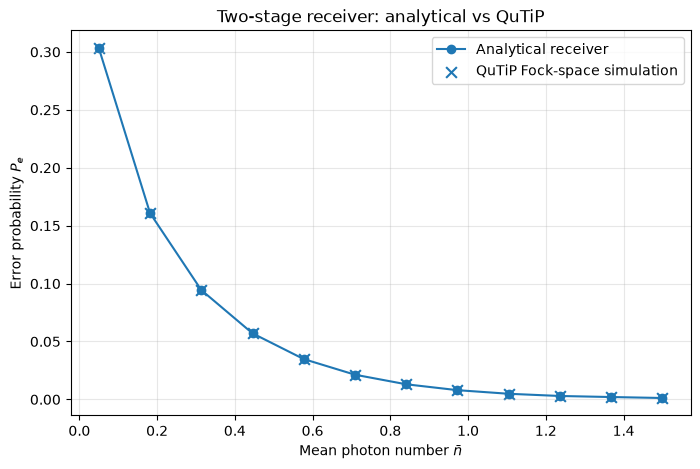

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    nbar_values,
    analytical_errors,
    marker="o",
    label="Analytical receiver"
)

ax.scatter(
    nbar_values,
    qutip_errors,
    marker="x",
    s=60,
    label="QuTiP Fock-space simulation"
)

ax.set_xlabel(r"Mean photon number $\bar{n}$")
ax.set_ylabel(r"Error probability $P_e$")
ax.set_title("Two-stage receiver: analytical vs QuTiP")

ax.grid(alpha=0.3)
ax.legend()

plt.show()

## Physical implementation of the displacement

So far, the receiver has applied the displacement operator $D(\beta)$
directly.

Experimentally, a displacement is implemented by interfering the signal
with a coherent local oscillator on a beam splitter.

The signal and local-oscillator inputs are

$$
|\alpha\rangle_s |\gamma\rangle_{\mathrm{LO}}.
$$

For a beam splitter with amplitude transmission $t$ and reflection $r$, the
signal output approximately has coherent amplitude

$$
t\alpha + r\gamma.
$$

Choosing

$$
\gamma = \frac{\beta}{r}
$$

therefore gives

$$
t\alpha + \beta.
$$

For a highly transmissive beam splitter, $t\approx1$, so

$$
t\alpha+\beta \approx \alpha+\beta,
$$

which is the action of the ideal displacement operator,

$$
D(\beta)|\alpha\rangle \propto |\alpha+\beta\rangle.
$$

We simulate this explicitly in QuTiP using two optical modes
and a beam-splitter unitary.

In [17]:
def beamsplitter_displacement(
    alpha,
    beta,
    transmission=0.90,
    cutoff=25
):

    t = np.sqrt(transmission)
    r = np.sqrt(1 - transmission)

    # Beam-splitter angle
    theta = np.arccos(t)

    # LO amplitude chosen so r * gamma = beta
    gamma = beta / r

    # Annihilation operators for signal and LO modes
    a = qt.tensor(
        qt.destroy(cutoff),
        qt.qeye(cutoff)
    )

    b = qt.tensor(
        qt.qeye(cutoff),
        qt.destroy(cutoff)
    )

    # Beam-splitter unitary
    U_bs = (
        theta * (a.dag() * b - a * b.dag())
    ).expm()

    # Input: signal + coherent local oscillator
    psi_in = qt.tensor(
        qt.coherent(cutoff, alpha),
        qt.coherent(cutoff, gamma)
    )

    # Pass both modes through beam splitter
    psi_out = U_bs * psi_in

    # Ignore the unused LO output port
    rho_signal = psi_out.ptrace(0)

    # Ideal mathematical displacement for comparison
    psi_ideal = (
        qt.displace(cutoff, beta)
        * qt.coherent(cutoff, alpha)
    )

    # Overlap with the ideal displaced state
    overlap = np.real(
        qt.expect(
            qt.ket2dm(psi_ideal),
            rho_signal
        )
    )

    return rho_signal, psi_ideal, overlap, gamma

In [18]:
nbar_test = 0.5

alpha = np.sqrt(nbar_test)
beta = -0.754771192291218

rho_bs, psi_ideal, overlap, gamma = beamsplitter_displacement(
    alpha,
    beta,
    transmission=0.90,
    cutoff=25
)

print("Signal amplitude alpha:", alpha)
print("Displacement beta:", beta)
print("Local oscillator amplitude:", gamma)
print("Overlap with ideal displacement:", overlap)

Signal amplitude alpha: 0.7071067811865476
Displacement beta: -0.754771192291218
Local oscillator amplitude: -2.3867960799211714
Overlap with ideal displacement: 0.9986841531471372


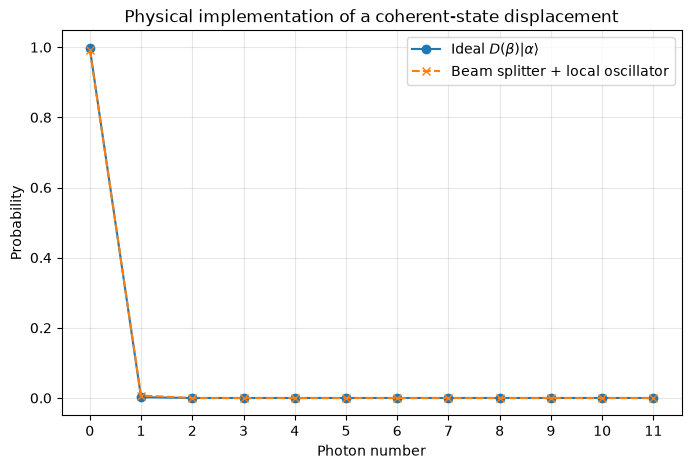

In [19]:
photon_numbers = np.arange(12)

p_bs = np.real(rho_bs.diag())[:12]

p_ideal = (
    np.abs(psi_ideal.full().ravel()) ** 2
)[:12]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    photon_numbers,
    p_ideal,
    marker="o",
    label=r"Ideal $D(\beta)|\alpha\rangle$"
)

ax.plot(
    photon_numbers,
    p_bs,
    marker="x",
    linestyle="--",
    label="Beam splitter + local oscillator"
)

ax.set_xlabel("Photon number")
ax.set_ylabel("Probability")
ax.set_title("Physical implementation of a coherent-state displacement")

ax.set_xticks(photon_numbers)
ax.grid(alpha=0.3)
ax.legend()

plt.show()

These plots are somewhat boring, but nonetheless validation for the analytical implementions we use.